In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
import xgboost as xgb

In [14]:
demand_raw = pd.read_excel('dataset/PGCB_date_power_demand.xlsx')

print(f"Demand data shape : {demand_raw.shape}")
print(f"Date range        : {demand_raw['datetime'].min()} → {demand_raw['datetime'].max()}")
print(f"Columns           : {demand_raw.columns.tolist()}")
demand_raw.head(3)

Demand data shape : (92650, 15)
Date range        : 2015-04-19 00:00:00 → 2025-06-17 12:00:00
Columns           : ['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'remarks']


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN


In [15]:
import os
folder_path = r'C:\Users\shiba\Documents\my_project\dataset\raw'
if os.path.exists(folder_path):
    print("Files found in folder:", os.listdir(folder_path))
else:
    print("The folder path itself is incorrect.")

The folder path itself is incorrect.


In [16]:
weather_file = pd.read_excel(r'C:\Users\shiba\OneDrive\Desktop\4i Lab\dataset\weather_data.xlsx', header=None)
weather_raw  = weather_file.iloc[4:].copy()
weather_raw.columns = [
    'datetime', 'temperature_c', 'humidity_pct', 'feels_like_temp_c',
    'rainfall_mm', 'dew_point_c', 'soil_temp_c', 'wind_direction_deg',
    'cloud_cover_pct', 'sunshine_hours',
]
weather_raw = weather_raw.reset_index(drop=True)
weather_raw['datetime'] = pd.to_datetime(weather_raw['datetime'])

WEATHER_COLS = [
    'temperature_c', 'humidity_pct', 'feels_like_temp_c', 'rainfall_mm',
    'dew_point_c', 'soil_temp_c', 'wind_direction_deg', 'cloud_cover_pct', 'sunshine_hours',
]
for col in WEATHER_COLS:
    weather_raw[col] = pd.to_numeric(weather_raw[col], errors='coerce')

print(f"Weather data shape : {weather_raw.shape}")
print(f"Date range         : {weather_raw['datetime'].min()} → {weather_raw['datetime'].max()}")
weather_raw.head(3)

Weather data shape : (107304, 10)
Date range         : 2014-01-01 00:00:00 → 2026-03-29 23:00:00


,datetime,temperature_c,humidity_pct,feels_like_temp_c,rainfall_mm,dew_point_c,soil_temp_c,wind_direction_deg,cloud_cover_pct,sunshine_hours
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0


In [18]:
economic_raw = pd.read_csv('dataset/economic_full_1.csv')

print(f"Economic data shape : {economic_raw.shape}")
print("Sample indicators :")
print(economic_raw['Indicator Name'].head(10).tolist())

Economic data shape : (1516, 69)
Sample indicators :
['Intentional homicides, male (per 100,000 male)', 'Battle-related deaths (number of people)', 'Voice and Accountability: Percentile Rank', 'Transport services (% of commercial service exports)', 'Computer, communications and other services (% of commercial service exports)', 'Merchandise exports by the reporting economy, residual (% of total merchandise exports)', 'Merchandise exports to low- and middle-income economies in Latin America & the Caribbean (% of total merchandise exports)', 'Merchandise exports to high-income economies (% of total merchandise exports)', 'Manufactures exports (% of merchandise exports)', 'Food exports (% of merchandise exports)']


In [19]:
EXTRA_PGCB_COLS = ['generation_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind']

df = demand_raw[['datetime', 'demand_mw'] + EXTRA_PGCB_COLS].copy()
df['demand_mw'] = pd.to_numeric(df['demand_mw'], errors='coerce')
for col in EXTRA_PGCB_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values('datetime').drop_duplicates(subset='datetime').reset_index(drop=True)
print(f" {len(df):,}")

full_timeline = pd.date_range(start=df['datetime'].min(), end=df['datetime'].max(), freq='h')
df = df.set_index('datetime').reindex(full_timeline)
df.index.name = 'datetime'
df = df.reset_index()
print(f" {len(df):,}")
print(f" {df['demand_mw'].isna().sum():,}")

 92,218
 89,101
 1,055


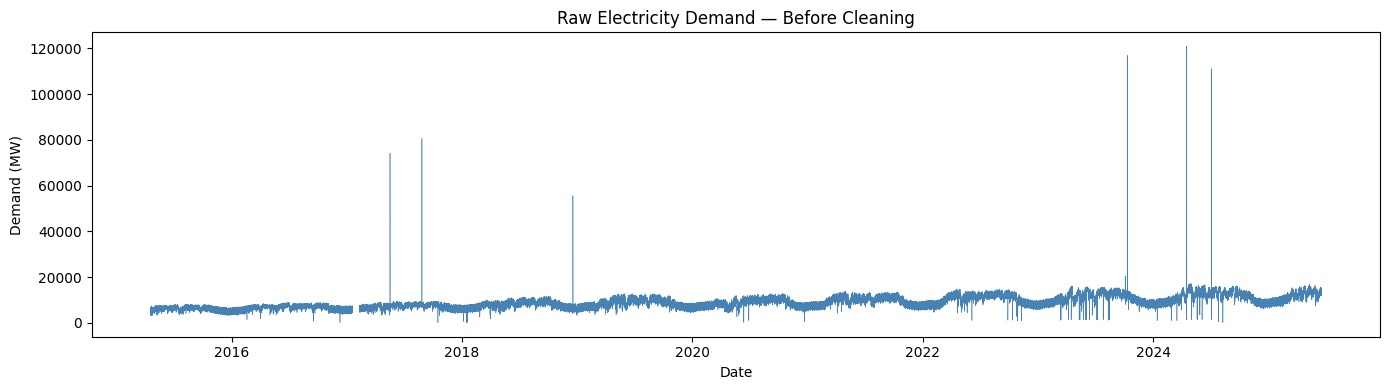

count     88046.000000
mean       8776.296209
std        2709.835241
min           6.000000
25%        6769.000000
50%        8381.000000
75%       10590.000000
max      121000.000000
Name: demand_mw, dtype: float64


In [20]:
plt.figure(figsize=(14, 4))
plt.plot(df['datetime'], df['demand_mw'], linewidth=0.4, color='steelblue')
plt.title('Raw Electricity Demand — Before Cleaning')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(df['demand_mw'].describe())

In [21]:
TRAIN_CUTOFF = '2024-01-01'

def compute_iqr_bounds(data: pd.DataFrame) -> dict:
    bounds = {}
    for month in range(1, 13):
        subset = data.loc[data['datetime'].dt.month == month, 'demand_mw'].dropna()
        if subset.empty:
            continue
        Q1, Q3 = subset.quantile(0.25), subset.quantile(0.75)
        IQR = Q3 - Q1
        bounds[month] = (Q1 - 3 * IQR, Q3 + 3 * IQR)
    return bounds

def apply_iqr_bounds(data: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    result = data.copy()
    for month, (lower, upper) in bounds.items():
        mask = result['datetime'].dt.month == month
        bad  = mask & ((result['demand_mw'] < lower) | (result['demand_mw'] > upper))
        result.loc[bad, 'demand_mw'] = np.nan
    return result


def fill_gaps(data: pd.DataFrame) -> pd.DataFrame:
   
    data = data.copy()
    data['demand_mw'] = (
        data['demand_mw']
        .interpolate(method='linear', limit=24)
        .bfill()
        .fillna(data['demand_mw'].median())
    )
    for col in EXTRA_PGCB_COLS:
        data[col] = data[col].ffill().bfill().fillna(0)
    return data

df_train_raw = df[df['datetime'] < TRAIN_CUTOFF].copy()
df_test_raw  = df[df['datetime'] >= TRAIN_CUTOFF].copy()

train_bounds   = compute_iqr_bounds(df_train_raw)
df_train_clean = fill_gaps(apply_iqr_bounds(df_train_raw, train_bounds))
df_test_clean  = fill_gaps(apply_iqr_bounds(df_test_raw,  train_bounds))

df = pd.concat([df_train_clean, df_test_clean]).sort_values('datetime').reset_index(drop=True)

print(df[['demand_mw'] + EXTRA_PGCB_COLS].isna().sum())
print("\n")
print(df[df['datetime'] < TRAIN_CUTOFF]['demand_mw'].describe())
print("\n")
print(df[df['datetime'] >= TRAIN_CUTOFF]['demand_mw'].describe())

demand_mw        0
generation_mw    0
load_shedding    0
gas              0
liquid_fuel      0
coal             0
hydro            0
solar            0
wind             0
dtype: int64


count    76296.000000
mean      8288.759798
std       2369.587517
min          6.000000
25%       6501.000000
50%       7939.500000
75%       9854.000000
max      20587.000000
Name: demand_mw, dtype: float64


count    12805.000000
mean     11445.751581
std       2367.218248
min        143.000000
25%       9649.000000
50%      11500.000000
75%      13300.000000
max      17200.000000
Name: demand_mw, dtype: float64


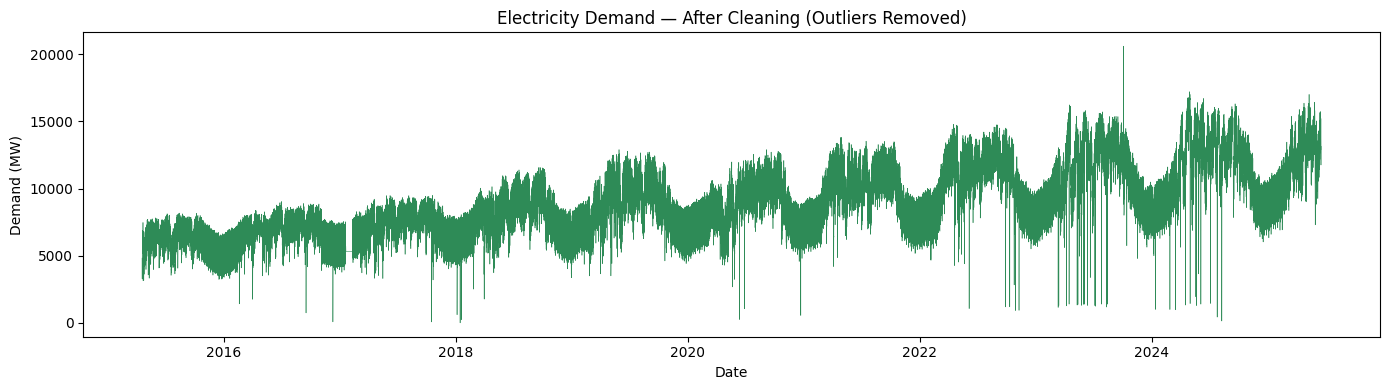

In [22]:
plt.figure(figsize=(14, 4))
plt.plot(df['datetime'], df['demand_mw'], linewidth=0.4, color='seagreen')
plt.title('Electricity Demand — After Cleaning (Outliers Removed)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

In [23]:
df = df.merge(weather_raw[['datetime'] + WEATHER_COLS], on='datetime', how='left')
df[WEATHER_COLS] = df[WEATHER_COLS].ffill().bfill()

print(f" {df.shape}")
print(f" {df[WEATHER_COLS].isna().sum().sum()}")

 (89101, 19)
 0


In [27]:
missing = [col for col in ECON_FEATURES if col not in df.columns]
print("Missing columns:", missing)

Missing columns: ['electricity_access_pct', 'electricity_per_person_kwh', 'gdp_growth_pct', 'gdp_per_person_usd', 'total_population', 'urban_growth_pct']


In [28]:
USEFUL_INDICATORS = [
    'GDP growth (annual %)',
    'GDP per capita (current US$)',
    'Access to electricity (% of population)',
    'Urban population growth (annual %)',
    'Population, total',
    'Electric power consumption (kWh per capita)',
]

INDICATOR_RENAME = {
    'GDP growth (annual %)':                       'gdp_growth_pct',
    'GDP per capita (current US$)':                'gdp_per_person_usd',
    'Access to electricity (% of population)':     'electricity_access_pct',
    'Urban population growth (annual %)':          'urban_growth_pct',
    'Population, total':                           'total_population',
    'Electric power consumption (kWh per capita)': 'electricity_per_person_kwh',
}

econ = economic_raw[economic_raw['Indicator Name'].isin(USEFUL_INDICATORS)].copy()
year_cols = [c for c in econ.columns if c.isdigit() and int(c) >= 2015]

econ_long = econ.melt(id_vars='Indicator Name', value_vars=year_cols,
                      var_name='year', value_name='value')
econ_long['year'] = econ_long['year'].astype(int)

econ_wide = (
    econ_long
    .pivot_table(index='year', columns='Indicator Name', values='value', aggfunc='first')
    .reset_index()
)
econ_wide.columns.name = None
econ_wide = econ_wide.rename(columns=INDICATOR_RENAME).sort_values('year').ffill()

ECON_FEATURES = [c for c in econ_wide.columns if c != 'year']
df['year'] = df['datetime'].dt.year

# --- ADD THIS LINE ---
# If the columns already exist (from a previous run), drop them first
cols_to_drop = [c for c in ECON_FEATURES if c in df.columns]
df = df.drop(columns=cols_to_drop)
# ---------------------

df = df.merge(econ_wide, on='year', how='left')
df[ECON_FEATURES] = df[ECON_FEATURES].ffill().bfill()

print(f" {df.shape}")
print(f" {df[ECON_FEATURES].isna().sum().sum()}")

 (89101, 38)
 0


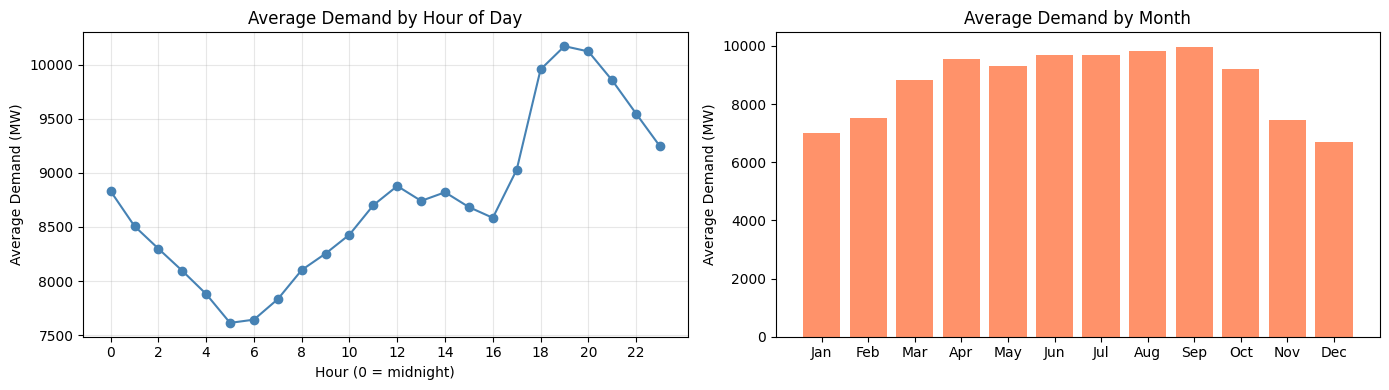

Peak hour  : 19:00
Peak month : Sep


In [29]:
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Average demand by hour of day
hourly_avg = df.groupby(df['datetime'].dt.hour)['demand_mw'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue')
axes[0].set_title('Average Demand by Hour of Day')
axes[0].set_xlabel('Hour (0 = midnight)')
axes[0].set_ylabel('Average Demand (MW)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

# Average demand by month
monthly_avg = df.groupby(df['datetime'].dt.month)['demand_mw'].mean()
axes[1].bar(range(1, 13), monthly_avg.values, color='coral', alpha=0.85)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(MONTH_LABELS)
axes[1].set_title('Average Demand by Month')
axes[1].set_ylabel('Average Demand (MW)')

plt.tight_layout()
plt.show()

print(f"Peak hour  : {hourly_avg.idxmax()}:00")
print(f"Peak month : {MONTH_LABELS[monthly_avg.idxmax() - 1]}")

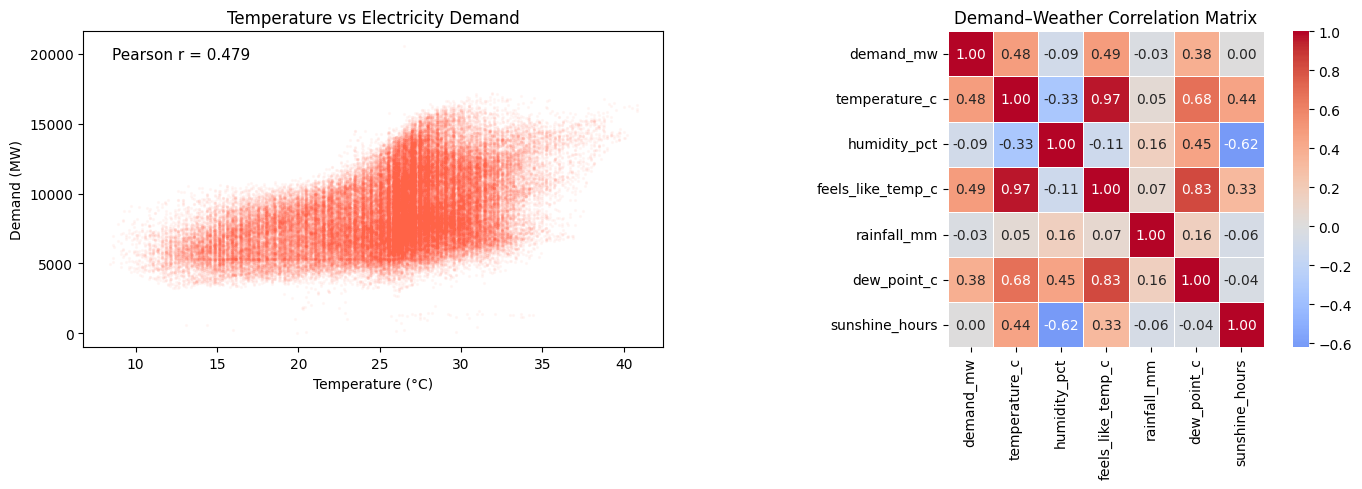

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature vs demand 
axes[0].scatter(df['temperature_c'], df['demand_mw'], alpha=0.04, s=2, color='tomato')
axes[0].set_title('Temperature vs Electricity Demand')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Demand (MW)')
axes[0].text(0.05, 0.95,
    f"Pearson r = {df['temperature_c'].corr(df['demand_mw']):.3f}",
    transform=axes[0].transAxes, fontsize=11, va='top')

# Demand–weather correlation heatmap
corr_cols = ['demand_mw', 'temperature_c', 'humidity_pct', 'feels_like_temp_c',
             'rainfall_mm', 'dew_point_c', 'sunshine_hours']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Demand–Weather Correlation Matrix')

plt.tight_layout()
plt.show()


In [ ]:
df = df.sort_values('datetime').reset_index(drop=True)

# Calendar features 
df['hour_of_day']    = df['datetime'].dt.hour
df['day_of_week']    = df['datetime'].dt.dayofweek  
df['month_of_year']  = df['datetime'].dt.month
df['quarter']        = df['datetime'].dt.quarter
df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)
df['is_summer']      = df['datetime'].dt.month.isin([6, 7, 8]).astype(int) 
df['is_monsoon_peak'] = df['datetime'].dt.month.isin([7, 8]).astype(int)   

# Cyclical encoding — prevents treating hour 23 and hour 0 as far apart
df['hour_sin']    = np.sin(2 * np.pi * df['hour_of_day']   / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour_of_day']   / 24)
df['month_sin']   = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month_of_year'] / 12)
df['weekday_sin'] = np.sin(2 * np.pi * df['day_of_week']   / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['day_of_week']   / 7)

In [ ]:

import holidays
bd_holidays = holidays.CountryHoliday('BD')

df['is_holiday'] = df['datetime'].apply(lambda x: 1 if x in bd_holidays else 0).astype(int)

# 2. Weather Rate of Change (Thermal Mass effect)
df['temp_change_3h'] = df['temperature_c'].diff(3).fillna(0)

# 3. Rolling Weather Stress
df['rolling_temp_24h'] = df['temperature_c'].rolling(window=24).mean().ffill().bfill()

print(f"Added holiday and weather stress features. New shape: {df.shape}")

Added holiday and weather stress features. New shape: (80340, 108)


In [ ]:
LAG_HOURS = [1, 2, 3, 4, 6, 12, 24, 48, 72, 96, 120, 144, 168]
for h in LAG_HOURS:
    df[f'demand_{h}h_ago'] = df['demand_mw'].shift(h)

df['demand_change_1h']  = df['demand_mw'].shift(1) - df['demand_mw'].shift(2)
df['demand_change_24h'] = df['demand_mw'].shift(1) - df['demand_mw'].shift(25)

df['demand_167h_ago'] = df['demand_mw'].shift(167)
df['demand_169h_ago'] = df['demand_mw'].shift(169)

df['demand_336h_ago'] = df['demand_mw'].shift(336)   
df['demand_504h_ago'] = df['demand_mw'].shift(504)   
df['demand_672h_ago'] = df['demand_mw'].shift(672)  

df['demand_8760h_ago'] = df['demand_mw'].shift(8760)


df['demand_8736h_ago'] = df['demand_mw'].shift(8736)  
df['demand_8784h_ago'] = df['demand_mw'].shift(8784)   
df['demand_yoy_anchor'] = df[['demand_8736h_ago', 'demand_8760h_ago', 'demand_8784h_ago']].mean(axis=1)
df['demand_yoy_growth'] = (df['demand_1h_ago'] / df['demand_yoy_anchor'] - 1).clip(-0.5, 0.5)

# Local trend: direction and speed of demand movement over last 7 days
df['demand_trend_7d'] = (df['demand_1h_ago'] - df['demand_168h_ago']) / 168

print(f" {len(LAG_HOURS) + 12}")

 25


In [33]:
demand_lagged = df['demand_mw'].shift(1)
TIME_WINDOWS  = [3, 6, 12, 24, 48, 168]

for w in TIME_WINDOWS:
    df[f'avg_demand_{w}h']         = demand_lagged.rolling(w, min_periods=1).mean()
    df[f'demand_variability_{w}h'] = demand_lagged.rolling(w, min_periods=1).std().fillna(0)

df['peak_demand_24h']   = demand_lagged.rolling(24, min_periods=1).max()
df['lowest_demand_24h'] = demand_lagged.rolling(24, min_periods=1).min()

daily_lag_cols = [f'demand_{h}h_ago' for h in [24, 48, 72, 96, 120, 144, 168]]
df['avg_same_hour_last_7d']         = df[daily_lag_cols].mean(axis=1)
df['variability_same_hour_last_7d'] = df[daily_lag_cols].std(axis=1).fillna(0)

# Sustained weather stress — captures prolonged August heat+humidity load
# All rolled on shift(1) so no look-ahead leak
humidity_lagged  = df['humidity_pct'].shift(1)
temp_lagged      = df['temperature_c'].shift(1)
df['avg_humidity_24h']          = humidity_lagged.rolling(24,  min_periods=1).mean()
df['avg_humidity_168h']         = humidity_lagged.rolling(168, min_periods=1).mean()
df['temp_humidity_interaction']  = temp_lagged * humidity_lagged / 100

In [34]:
GRID_STATE_COLS = ['generation_mw', 'gas', 'liquid_fuel', 'coal']

for col in GRID_STATE_COLS:
    df[f'{col}_1h_ago']  = df[col].shift(1)
    df[f'{col}_24h_ago'] = df[col].shift(24)

GRID_STATE_FEATURES = [f'{col}_{lag}' for col in GRID_STATE_COLS for lag in ['1h_ago', '24h_ago']]
print( GRID_STATE_FEATURES)
['generation_mw_1h_ago', 'generation_mw_24h_ago', 'gas_1h_ago', 'gas_24h_ago', 'liquid_fuel_1h_ago', 'liquid_fuel_24h_ago', 'coal_1h_ago', 'coal_24h_ago']
# Define supervised learning target
df['next_hour_demand_mw'] = df['demand_mw'].shift(-1)
df = df.dropna(subset=['next_hour_demand_mw', 'demand_504h_ago', 'demand_8760h_ago']).reset_index(drop=True)

print(f" {df.shape}")
print(f" {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f" {len(df):,}")

['generation_mw_1h_ago', 'generation_mw_24h_ago', 'gas_1h_ago', 'gas_24h_ago', 'liquid_fuel_1h_ago', 'liquid_fuel_24h_ago', 'coal_1h_ago', 'coal_24h_ago']
 (80340, 105)
 2016-04-18 → 2025-06-17
 80,340


In [40]:
from sklearn.model_selection import TimeSeriesSplit

# Prepare features and target
EXCLUDE_COLS = ['datetime', 'demand_mw', 'year', 'next_hour_demand_mw'] + EXTRA_PGCB_COLS
FEATURE_COLUMNS = [col for col in df.columns if col not in EXCLUDE_COLS]

X = df[FEATURE_COLUMNS]
y = df['next_hour_demand_mw'].values

# Initialize TimeSeriesSplit (5-fold)
tscv = TimeSeriesSplit(n_splits=5)

print("Starting Time-Series Cross-Validation...")
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_index], X.iloc[test_index]
    y_tr, y_val = y[train_index], y[test_index]
    print(f"Fold {fold+1}: Train size={len(X_tr)}, Validation size={len(X_val)}")



Starting Time-Series Cross-Validation...
Fold 1: Train size=13390, Validation size=13390
Fold 2: Train size=26780, Validation size=13390
Fold 3: Train size=40170, Validation size=13390
Fold 4: Train size=53560, Validation size=13390
Fold 5: Train size=66950, Validation size=13390


In [ ]:
RUN_rf_TUNING = False 

rf_best_params = {
    'n_estimators': 100,    
    'max_depth': 15,        
    'min_samples_leaf': 10, 
    'max_samples': 0.5,     
    'n_jobs': -1,           
    'random_state': 42
}


if RUN_rf_TUNING:
    print(" Hyperparameter Tuning")
    
    rf_tuning_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

    rf_param_grid = {
        'rf__n_estimators': [200, 300, 400],
        'rf__max_depth': [15, 20, 25],
        'rf__min_samples_leaf': [2, 5, 10]
    }

    rf_grid_search = GridSearchCV(
        estimator=rf_tuning_pipe,
        param_grid=rf_param_grid,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1,
        verbose=1
    )

    rf_grid_search.fit(X_train, y_train)
    rf_best_params = {k.replace('rf__', ''): v for k, v in rf_grid_search.best_params_.items()}
    print(f"{rf_best_params}")



rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(**rf_best_params))
])

# final model
rf_pipeline.fit(X_train, y_train)
rf_predictions = rf_pipeline.predict(X_test)

rf_mape = mean_absolute_percentage_error(y_test, rf_predictions) * 100
rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
rf_r2   = r2_score(y_test, rf_predictions)

print(f"\n{'='*30}")
print(f"Random Forest Final Results")
print(f"{'='*30}")
print(f"  MAPE : {rf_mape:.2f}%")
print(f"  MAE  : {rf_mae:.0f} MW")
print(f"  RMSE : {rf_rmse:.0f} MW")
print(f"  R²   : {rf_r2:.4f}")



Random Forest Final Results
  MAPE : 4.53%
  MAE  : 352 MW
  RMSE : 578 MW
  R²   : 0.9404


In [ ]:
RUN_xgb_TUNING = False  

xgb_best_params = {
    'n_estimators': 800,
    'learning_rate': 0.02,
    'max_depth': 7,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'min_child_weight': 3,
    'random_state': 42,
    'eval_metric': 'mape'
}
# hyper tunning
if RUN_xgb_TUNING:
    print(" Hyperparameter Tuning")
    
    tuning_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', xgb.XGBRegressor(random_state=42, eval_metric='mape'))
    ])

    xgb_param_grid = {
        'xgb__n_estimators': [500, 800, 1000],
        'xgb__learning_rate': [0.01, 0.02, 0.03],
        'xgb__max_depth': [5, 7, 9],
        'xgb__subsample': [0.8, 1.0],
        'xgb__colsample_bytree': [0.7, 0.8],
        'xgb__min_child_weight': [1, 3, 5]
    }

    xgb_grid_search = GridSearchCV(
        estimator=tuning_pipe,
        param_grid=xgb_param_grid,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1,  
        verbose=1
    )

    xgb_grid_search.fit(X_train, y_train)
    xgb_best_params = {k.replace('xgb__', ''): v for k, v in xgb_grid_search.best_params_.items()}
    print(f" {xgb_best_params}")

# final model
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(**xgb_best_params))
])
xgb_pipeline.fit(X_train, y_train)
xgb_predictions = xgb_pipeline.predict(X_test)

xgb_mape = mean_absolute_percentage_error(y_test, xgb_predictions) * 100
xgb_mae  = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = mean_squared_error(y_test, xgb_predictions) ** 0.5
xgb_r2   = r2_score(y_test, xgb_predictions)

print(f"\n{'='*30}")
print(f"XGBoost Final Results")
print(f"{'='*30}")
print(f"  MAPE : {xgb_mape:.2f}%")
print(f"  MAE  : {xgb_mae:.0f} MW")
print(f"  RMSE : {xgb_rmse:.0f} MW")
print(f"  R²   : {xgb_r2:.4f}")



XGBoost Final Results
  MAPE : 4.66%
  MAE  : 385 MW
  RMSE : 626 MW
  R²   : 0.9301


In [ ]:


from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error
import xgboost as xgb


rf_fast = RandomForestRegressor(
    n_estimators=100,     
    max_depth=10,          
    max_samples=0.5,     
    n_jobs=-1,            
    random_state=42
)


xgb_fast = xgb.XGBRegressor(
    n_estimators=150,     
    max_depth=6,          
    tree_method='hist',    
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)


base_models = [
    ('rf', rf_fast),
    ('xgb', xgb_fast)
]


stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(),
    cv=2,          # Reduced from 3/5 to 2 folds
    n_jobs=1,      # Avoid nested parallelism
    passthrough=False
)


stacking_pipeline = Pipeline([
    ('stack', stacking_model)
])


print("Training Optimized Stacking Ensemble...")

stacking_pipeline.fit(X_train, y_train)

stack_preds = stacking_pipeline.predict(X_test)

stack_mape = mean_absolute_percentage_error(y_test, stack_preds) * 100

print(f"Stacking Ensemble MAPE: {stack_mape:.2f}%")

Training Optimized Stacking Ensemble...
Stacking Ensemble MAPE: 6.21%


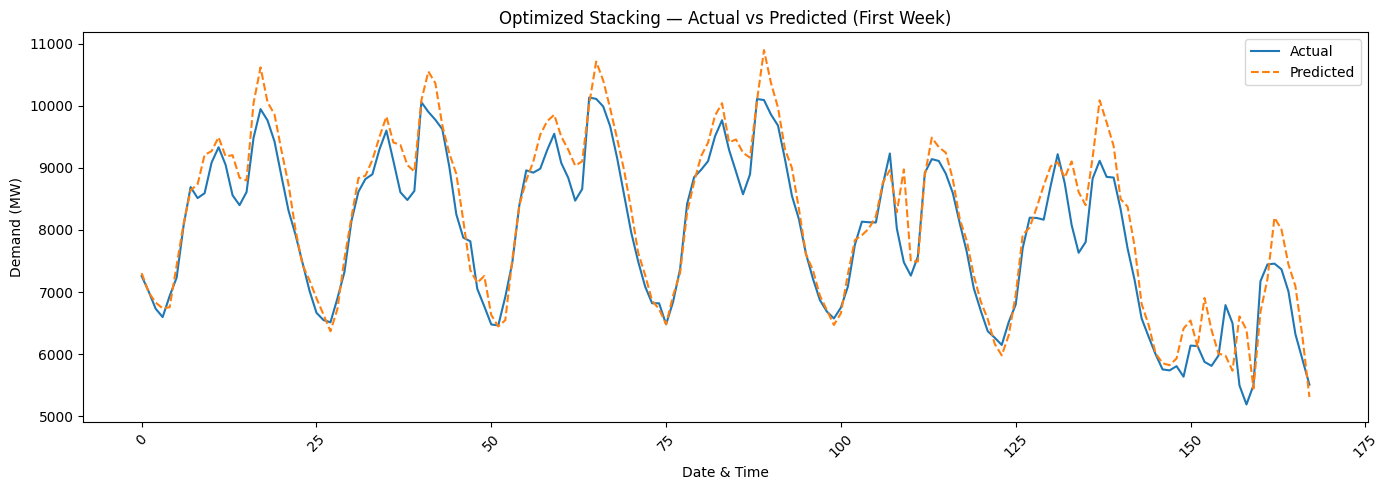

In [ ]:


best_predictions = stacking_pipeline.predict(X_test)
best_model_name = "Optimized Stacking"



import matplotlib.pyplot as plt
import pandas as pd


y_test_series = pd.Series(y_test).reset_index(drop=True)

if 'datetime' in X_test.columns:
    datetime_series = X_test['datetime'].reset_index(drop=True)
else:
    datetime_series = pd.RangeIndex(start=0, stop=len(y_test_series), step=1)

first_week_actual = y_test_series.iloc[:168]
first_week_pred = best_predictions[:168]
first_week_time = datetime_series[:168]



plt.figure(figsize=(14, 5))

plt.plot(first_week_time,
         first_week_actual,
         label='Actual',
         linewidth=1.5)

plt.plot(first_week_time,
         first_week_pred,
         label='Predicted',
         linestyle='--',
         linewidth=1.5)

plt.title(f'{best_model_name} — Actual vs Predicted (First Week)')
plt.xlabel('Date & Time')
plt.ylabel('Demand (MW)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

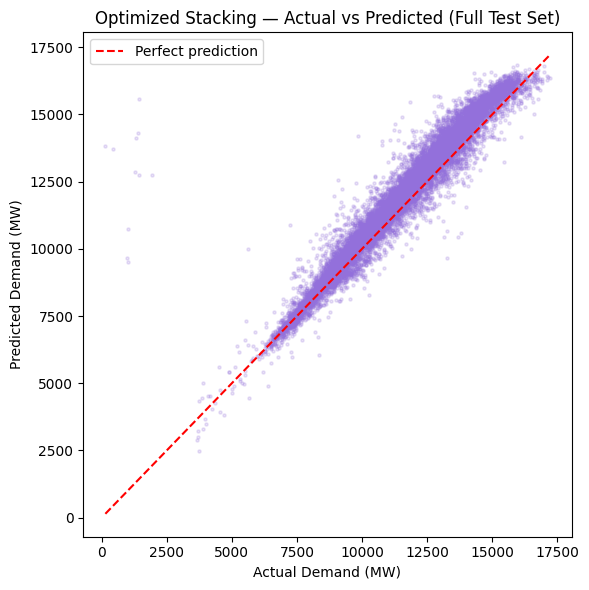

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_predictions, alpha=0.2, s=5, color='mediumpurple')
axis_lim = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
plt.plot(axis_lim, axis_lim, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Demand (MW)')
plt.ylabel('Predicted Demand (MW)')
plt.title(f'{best_model_name} — Actual vs Predicted (Full Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:


import pandas as pd

# Access stacking model inside pipeline
stack_model = stacking_pipeline.named_steps['stack']

# Access Random Forest model
rf_model = stack_model.named_estimators_['rf']

# Create importance dataframe
feature_importance_df = (
    pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_model.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print(feature_importance_df.head(15))

                 feature  importance
0          demand_1h_ago    0.775086
1   generation_mw_1h_ago    0.105481
2        demand_167h_ago    0.028736
3               hour_sin    0.019114
4               hour_cos    0.015669
5         demand_24h_ago    0.014426
6         avg_demand_24h    0.003579
7            hour_of_day    0.003011
8          demand_4h_ago    0.002700
9       demand_change_1h    0.002515
10         avg_demand_6h    0.002064
11        demand_12h_ago    0.001997
12         temperature_c    0.001989
13       demand_169h_ago    0.001273
14         demand_6h_ago    0.001201


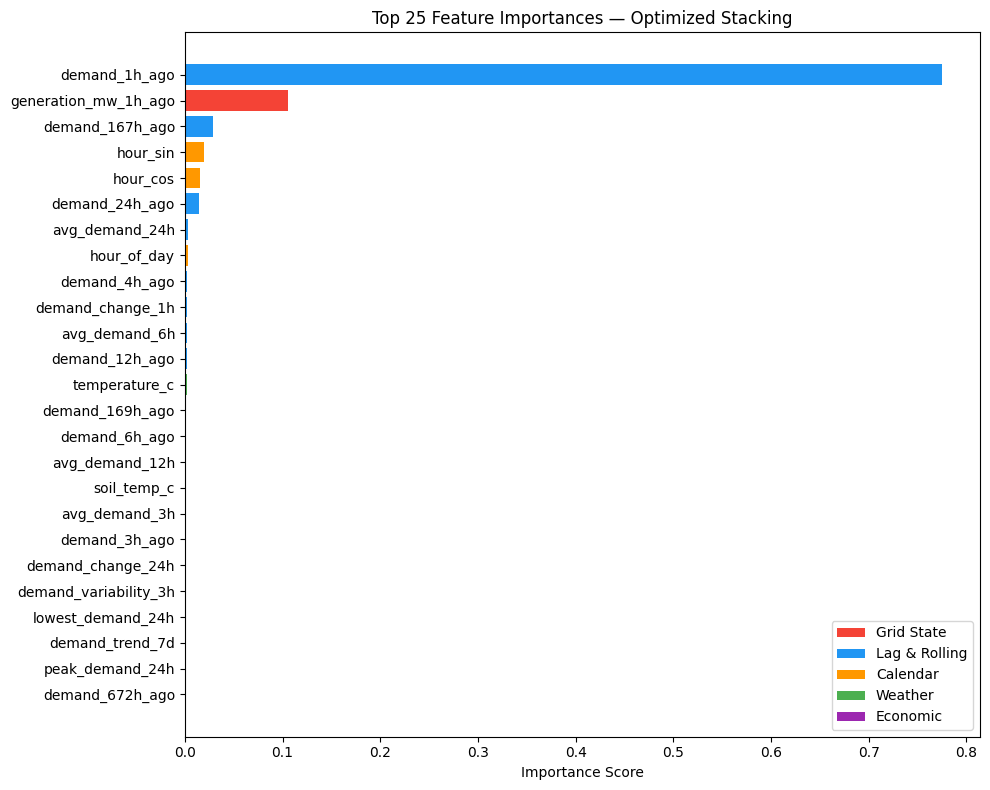

In [56]:
CATEGORY_COLOURS = {
    'Grid State'   : '#F44336',
    'Lag & Rolling': '#2196F3',
    'Calendar'     : '#FF9800',
    'Weather'      : '#4CAF50',
    'Economic'     : '#9C27B0',
}

def classify_feature(name: str) -> str:
    if name in GRID_STATE_FEATURES:
        return 'Grid State'
    if 'demand' in name and any(k in name for k in
            ['ago', 'avg', 'peak', 'variability', 'lowest', 'change', 'same_hour']):
        return 'Lag & Rolling'
    if any(k in name for k in
            ['hour', 'month', 'day', 'week', 'quarter', 'weekend', 'sin', 'cos', 'summer']):
        return 'Calendar'
    if name in WEATHER_COLS:
        return 'Weather'
    return 'Economic'

feature_importance_df['category'] = feature_importance_df['feature'].apply(classify_feature)
feature_importance_df['colour']   = feature_importance_df['category'].map(CATEGORY_COLOURS)

top25 = feature_importance_df.head(25)

plt.figure(figsize=(10, 8))
plt.barh(top25['feature'][::-1], top25['importance'][::-1], color=top25['colour'][::-1])
plt.xlabel('Importance Score')
plt.title(f'Top 25 Feature Importances — {best_model_name}')
plt.legend(
    handles=[Patch(facecolor=c, label=l) for l, c in CATEGORY_COLOURS.items()],
    loc='lower right'
)
plt.tight_layout()
plt.show()

Feature Category Importance:
  Lag & Rolling  : 84.6%
  Grid State     : 10.7%
  Calendar       : 3.9%
  Weather        : 0.5%
  Economic       : 0.2%


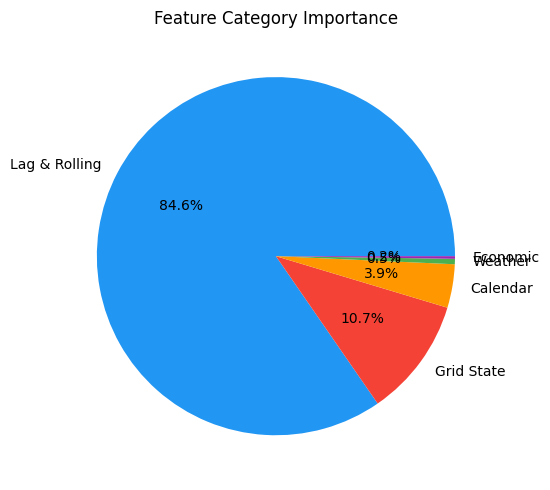

In [57]:
category_totals = (
    feature_importance_df.groupby('category')['importance'].sum()
    .sort_values(ascending=False)
)

print("Feature Category Importance:")
for cat, score in category_totals.items():
    print(f"  {cat:<15}: {score * 100:.1f}%")

plt.figure(figsize=(6, 5))
category_totals.plot(
    kind='pie', autopct='%1.1f%%',
    colors=[CATEGORY_COLOURS[c] for c in category_totals.index]
)
plt.title('Feature Category Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [61]:


from sklearn.base import clone
import numpy as np
import pandas as pd

# Combine train + test
X_final = pd.concat([X_train, X_test]).reset_index(drop=True)
y_final = np.concatenate([y_train, y_test])

# Clone stacking pipeline
final_pipeline = clone(stacking_pipeline)

# Fit on full dataset
final_pipeline.fit(X_final, y_final)

print(f"Final model trained on {len(X_final):,} rows using Optimized Stacking")

Final model trained on 80,340 rows using Optimized Stacking
